#Cosmic Ray and Earthquake analysis
Last updated 21/9/21 J. Devine

##This is what I was planning to do - I didn't get very far.

Stage 1: Collect the data
datasets - nmdb data (all stations, corrected rates) (done!)
USGS Earthquake db (done!)
Sunspot data - cross ref with cosmics and earthquakes.
Weather data - nearest neighbour for each NMDB location (not done - would be nice in the future)


Stage 2: Back-calc the pressure correction - not done!
    a - cross ref. air pressure with nearest neighbour
    b - compare raw and corrected counts
    c - compare delta with pressure data sets
    d - compute correction constant
    e - compute pressure /cosmic rate correlation

Then repeat for sunspot data. sunspot correlation with cosmics (expected -ve and strong)

Stage 3: Earthquake data
structure 10 year data (2010-2020), inc. 6 hourly averages of seismic energy. 
plot all earthquake locations (lat/long) to see fault lines
Find the nearest nmdb sensor for each (actually find nearest earthquakes for each nmdb..).
Compute for each earthquake the distances to NMDB sites (triangulation)


Stage 4:
Windows. 
Window variables - averages from 1m to 4 weeks (compute for cosmic and seismic from raw)
Window variable - W
Offset variable - look at all offsets from 1m to 365 days (+ and -)
In each case perform a regression across the dataset and select for highest correlations.


Stage 5: Random variable
Pick a random variable from the weather data and do a null analysis.

##What I actually did (so far)
Import data from NMDB monitors, for basically all the sites, all date ranges and build arrays (pandas), and rescale per period.
Import data from USGS and compute average seismic activity per period
Import sunspot data and compute average sunsport data per period

Correlation between USGS and sunspot data, with p values, across a range of offsets up to +/-10k days- interesting patterns!

##What is left to do to make this useful
Wrangle the NMDB data properly to do a similar variable offset calc with USGS data. 
If the correlations and p values are reasonable at specific offsets then - 
Compare this analysis with c(P,t0,d,m,𝚫t) = A*B = (Sm(ti+𝚫t)/M(Sm(ti+𝚫t))-1))*(|𝚫ncr(ti,i-1)|/M(|𝚫ncr(ti,i-1)|)-1) 
Build a PDF for agreement etc.



In [4]:
import argparse, csv, urllib.request, time
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from pandas.tseries.offsets import DateOffset
import matplotlib.pyplot as plot

In [5]:
from scipy.stats import kendalltau, pearsonr, spearmanr

def kendall_pval(x,y):
    return kendalltau(x,y)[1]
    
def pearsonr_pval(x,y):
    return pearsonr(x,y)[1]
    
def spearmanr_pval(x,y):
    return spearmanr(x,y)[1]

In [6]:
from platform import python_version
print(python_version())

3.9.5


In [7]:
def log_avg(spl_arraylike):
  return 10*np.log10(np.mean(np.power(10, spl_arraylike/10)))

In [8]:
average_interval = "1D"
print ("Start with the interval ", average_interval)

Start with the interval  1D


In [9]:
station_names = [
    "AATA","AATB","APTY","ARNM","ATHN","BKSN",
    "CALM","DJON","DOMB","DOMC","DRBS","FSMT",
    "HRMS","INVK","IRK2","IRK3","IRKT","JBGO",
    "JUNG","JUNG1","KERG","KIEL","KIEL2","LMKS",
    "MCRL","MGDN","MOSC","MRNY","MXCO","NAIN",
    "NANM","NEWK","NRLK","OULU","PSNM","PTFM",
    "PWNK","ROME","SNAE","SOPB","SOPO","TERA",
    "THUL","TSMB"
]

In [10]:
start_date = [ "1", "1", "1960", "0", "0"]
end_date = ["31", "12", "2019", "23", "59"]

In [11]:
# load all the stations
for current_station in station_names:
    for i in range(int(start_date[2]), int(end_date[2])+1):
        station_file = Path(current_station+str(i)+'.csv')
        if not station_file.exists():
            URL = "http://nest.nmdb.eu/draw_graph.php?wget=1&stations[]="+current_station+"&tabchoice=1h&dtype=corr_for_pressure&output=ascii&date_choice=bydate&last_label=days_label&tresolution=60&force=0&start_day="+start_date[0]+"&start_month="+start_date[1]+"&start_year="+str(i)+"&start_hour="+start_date[3]+"&start_min="+start_date[4]+"&end_day="+end_date[0]+"&end_month="+end_date[1]+"&end_year="+str(i)+"&end_hour="+end_date[3]+"&end_min="+end_date[4]+"&yunits=0"
            print(URL)
            try:
                req = urllib.request.Request(URL)
            #req.add_header('User-Agent', 'urllib/0.1')
                with urllib.request.urlopen(req) as f:
                    content = f.readlines()
                    fromhere = False
                    content_p = ""
                    for line in content:
                        if "start_date_time" in line.decode("utf-8", "strict"):
                            fromhere = True
                        if fromhere:
                            content_p =  content_p+ line.decode()
                with station_file.open('wt') as fh:
                    fh.write(content_p)
                    fh.close
                time.sleep(1)
                #print(current_station+'completed ' + str(i))
            except:
                print("An exception occurred with "+str(station_file))
            #time.sleep(6)
    print(current_station+'fully completed')
print("finished")


AATAfully completed
AATBfully completed
APTYfully completed
ARNMfully completed
ATHNfully completed
BKSNfully completed
CALMfully completed
DJONfully completed
DOMBfully completed
DOMCfully completed
DRBSfully completed
FSMTfully completed
HRMSfully completed
INVKfully completed
http://nest.nmdb.eu/draw_graph.php?wget=1&stations[]=IRK2&tabchoice=1h&dtype=corr_for_pressure&output=ascii&date_choice=bydate&last_label=days_label&tresolution=60&force=0&start_day=1&start_month=1&start_year=2015&start_hour=0&start_min=0&end_day=31&end_month=12&end_year=2015&end_hour=23&end_min=59&yunits=0
An exception occurred with IRK22015.csv
IRK2fully completed
http://nest.nmdb.eu/draw_graph.php?wget=1&stations[]=IRK3&tabchoice=1h&dtype=corr_for_pressure&output=ascii&date_choice=bydate&last_label=days_label&tresolution=60&force=0&start_day=1&start_month=1&start_year=2015&start_hour=0&start_min=0&end_day=31&end_month=12&end_year=2015&end_hour=23&end_min=59&yunits=0
An exception occurred with IRK32015.csv
IR

In [12]:
# Populate data structures
start_date = [ "1", "1", "1960", "0", "0"]
end_date = ["31", "12", "2019", "23", "59"]
combineddata = []
for current_station in station_names:
    listofcosmics = []
    for i in range(int(start_date[2]), int(end_date[2])+1):
        station_file = Path(current_station+str(i)+'.csv')
        try:
            readframe = (pd.read_csv(station_file,sep=';',skiprows=1,names = ['start_date_time', current_station],parse_dates=['start_date_time'], index_col=['start_date_time']))
            #print("Opened "+str(station_file))
        except:
            print("An exception occurred, "+str(station_file))
        listofcosmics.append(readframe)
    listofcosmics[0] = pd.merge(listofcosmics[0],listofcosmics[1],  how='outer', left_index=True, right_index=True)
    listofcosmics[0] = listofcosmics[0].fillna(0)
    listofcosmics[0][current_station] = listofcosmics[0][str(current_station+"_x")] + listofcosmics[0][str(current_station+"_y")]
    listofcosmics[0] = listofcosmics[0].drop(columns=[str(current_station+'_x'), str(current_station+'_y')])
    howmanyitems = len(listofcosmics)
    for i in range(2, howmanyitems):
        listofcosmics[0] = pd.merge(listofcosmics[0],listofcosmics[i],  how='outer', left_index=True, right_index=True)
        listofcosmics[0] = listofcosmics[0].fillna(0)
        listofcosmics[0][current_station] = listofcosmics[0][str(current_station+"_x")] + listofcosmics[0][str(current_station+"_y")]
        listofcosmics[0] = listofcosmics[0].drop(columns=[str(current_station+"_x"), str(current_station+"_y")])
    combineddata.append(listofcosmics[0])
print("finished")

An exception occurred, IRK22015.csv
An exception occurred, IRK32015.csv
An exception occurred, NRLK2015.csv
finished


In [13]:
#check that thte sequences match
print(station_names)
print(combineddata[0])

['AATA', 'AATB', 'APTY', 'ARNM', 'ATHN', 'BKSN', 'CALM', 'DJON', 'DOMB', 'DOMC', 'DRBS', 'FSMT', 'HRMS', 'INVK', 'IRK2', 'IRK3', 'IRKT', 'JBGO', 'JUNG', 'JUNG1', 'KERG', 'KIEL', 'KIEL2', 'LMKS', 'MCRL', 'MGDN', 'MOSC', 'MRNY', 'MXCO', 'NAIN', 'NANM', 'NEWK', 'NRLK', 'OULU', 'PSNM', 'PTFM', 'PWNK', 'ROME', 'SNAE', 'SOPB', 'SOPO', 'TERA', 'THUL', 'TSMB']
                        AATA
start_date_time             
2019-01-04 06:59:00  3775.33
2019-01-04 07:59:00  3781.68
2019-01-04 08:59:00  3773.55
2019-01-04 09:59:00  3831.31
2019-01-04 10:59:00  3784.70
...                      ...
2019-12-31 19:59:00  3756.13
2019-12-31 20:59:00  3774.63
2019-12-31 21:59:00  3747.15
2019-12-31 22:59:00  3781.48
2019-12-31 23:59:00  3761.70

[8105 rows x 1 columns]


In [14]:
# random sample test of one
print(combineddata[43])

                        TSMB
start_date_time             
1976-12-04 00:00:00  330.556
1976-12-04 01:00:00  330.972
1976-12-04 02:00:00  330.694
1976-12-04 03:00:00  331.139
1976-12-04 04:00:00  330.500
...                      ...
2019-11-01 19:00:00  332.000
2019-11-01 20:00:00  332.139
2019-11-01 21:00:00  331.583
2019-11-01 22:00:00  331.639
2019-11-01 23:00:00  332.000

[335841 rows x 1 columns]


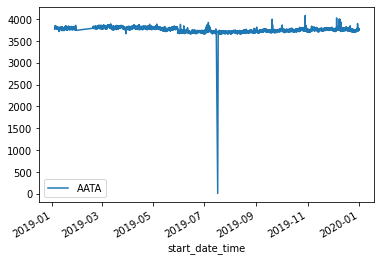

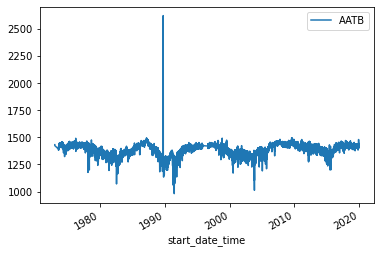

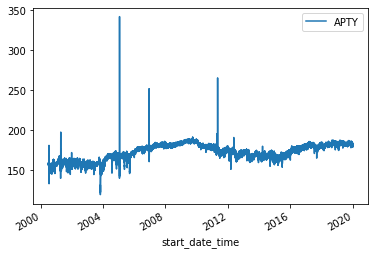

In [15]:
# plot several stations to check it makes sense
for station in range (0, 3):
 
    combineddata[station].plot()

In [16]:
# seismic data read in
sfs = []
start_year = 1960
end_year = 2019
types_dict = {'time':float, 'latitude':"string", 'longitude':"string", 'depth':"string", 'mag':"string"}
for i in range(start_year, end_year+1):
    sfs.append(pd.read_csv('siesmic-'+str(i)+'.csv',sep=',',skiprows=1,names = ['time', 'latitude', 'longitude', 'depth', 'mag'],parse_dates=['time'],index_col=['time'],usecols = [i for i in range(5)],dtype=types_dict))
sframe= pd.concat(sfs)
print(sframe)

                                    latitude longitude  depth   mag
time                                                               
1960-01-02 12:21:58+00:00            -55.877     -1.89     15   6.3
1960-01-02 22:51:46.080000+00:00  35.5563333  -121.351      6  4.04
1960-01-03 11:24:05+00:00               43.7    84.542     15   5.7
1960-01-04 06:16:35+00:00             11.374    42.609     15   6.1
1960-01-04 12:52:00+00:00             45.069    26.829     40   5.4
...                                      ...       ...    ...   ...
2019-12-31 19:02:55.645000+00:00     44.0786  150.2151     10   4.8
2019-12-31 19:10:10.306000+00:00      24.074  121.6908  12.21   4.6
2019-12-31 23:07:42.730000+00:00     17.9226  -66.8408      5   4.2
2019-12-31 23:09:44.616000+00:00      9.9422  -84.4593  59.75     4
2019-12-31 23:56:59.933000+00:00    -20.5382  168.9571  21.46   4.3

[427535 rows x 4 columns]


In [17]:
# manipulation with seismic data
cols = sframe.columns
print(cols)
#cols.remove('time')
sframe['latitude'] = pd.to_numeric(sframe['latitude'], errors='coerce')
sframe['longitude'] = pd.to_numeric(sframe['longitude'], errors='coerce')
sframe['depth'] = pd.to_numeric(sframe['depth'], errors='coerce')
sframe['mag'] = pd.to_numeric(sframe['mag'], errors='coerce')
#print(sframe.dtypes)
#sframe=pd.convert_objects(convert_numeric=True)
#for col in cols:
#    sframe[col] = sframe[col].astype(float)
#sframe.index.tz_convert(None)
#sframe.tz_localize(None)
sframe_notz = sframe.tz_convert(None)
daily_quakes = sframe_notz.resample(average_interval, origin='1960-01-01').apply(lambda spl: 10*np.log10(np.mean(np.power(10, spl/10))))
daily_quakes = daily_quakes.fillna(0)

Index(['latitude', 'longitude', 'depth', 'mag'], dtype='object')


<AxesSubplot:xlabel='time'>

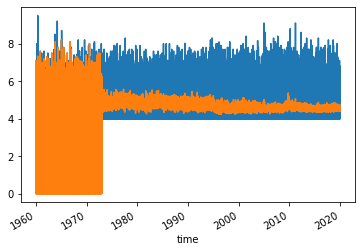

In [18]:
# plot the quake data
sframe['mag'].plot()
daily_quakes['mag'].plot()


In [19]:
print ("Start Sunspots!")




Start Sunspots!


In [20]:
# load the sunspot data
sun_file = Path('sunspots.csv')
content_p = ""
if not sun_file.exists():
    URL = "http://cesar.kso.ac.at/sunspot_numbers/daily_sn.csv"
    print(URL)
    req = urllib.request.Request(URL)
    req.add_header('User-Agent', 'urllib/0.1')
    with urllib.request.urlopen(req) as f:
        content = f.readlines()
        for line in content:
            content_p =  content_p+ line.decode()
    with sun_file.open('wt') as fh:
        fh.write(content_p)
        fh.close

In [23]:
# data manipulations with sunspots
sunframe = []
sun_types_dict = {'time':float, 'total':"string", 'sn':"string", 'ss':"string", 'diff':"string"}
sunframe.append(pd.read_csv(sun_file,sep=';',skiprows=0,names = ['time', 'tot', 'sn', 'ss', 'diff'],parse_dates=['time'],index_col=['time'],dtype=sun_types_dict))
sundf= (pd.read_csv(sun_file,sep=';',skiprows=0,names = ['time', 'tot', 'sn', 'ss', 'diff'],parse_dates=['time'],index_col=['time'],dtype=sun_types_dict))

print(sunframe[0])
print(sundf)
print(sundf.dtypes)
sundf['sn'] = pd.to_numeric(sundf['sn'], errors='coerce')
sundf['ss'] = pd.to_numeric(sundf['ss'], errors='coerce')
sundf['diff'] = pd.to_numeric(sundf['diff'], errors='coerce')
print(sundf.dtypes)

daily_sunspots = sundf.resample(average_interval, origin='1960-01-01').mean()

print(daily_sunspots)

            tot    sn    ss   diff
time                              
1944-06-05   23    0   -23   -23  
1944-06-13    0    0     0     0  
1944-06-14    0    0     0     0  
1944-06-16    0    0     0     0  
1944-06-21    0    0     0     0  
...         ...   ...   ...    ...
2021-06-29   61   10   -51     -41
2021-06-30   69   21   -48     -26
2021-07-01   53   11   -42     -30
2021-07-02   67   21   -46     -25
2021-07-03   76   23   -53     -29

[21022 rows x 4 columns]
            tot    sn    ss   diff
time                              
1944-06-05   23    0   -23   -23  
1944-06-13    0    0     0     0  
1944-06-14    0    0     0     0  
1944-06-16    0    0     0     0  
1944-06-21    0    0     0     0  
...         ...   ...   ...    ...
2021-06-29   61   10   -51     -41
2021-06-30   69   21   -48     -26
2021-07-01   53   11   -42     -30
2021-07-02   67   21   -46     -25
2021-07-03   76   23   -53     -29

[21022 rows x 4 columns]
tot      int64
sn      string
ss      

<AxesSubplot:xlabel='time'>

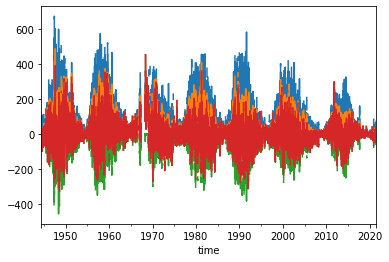

In [24]:
# plot the sunspot progress
daily_sunspots['tot'].plot()
daily_sunspots['sn'].plot()
daily_sunspots['ss'].plot()
daily_sunspots['diff'].plot()

<AxesSubplot:xlabel='time'>

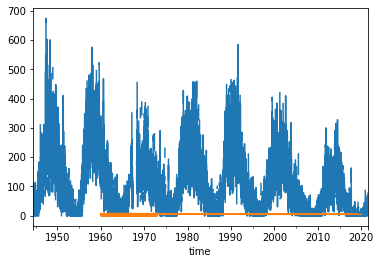

In [25]:
# show sunspot cycle
daily_sunspots['tot'].plot()
daily_quakes['mag'].plot()


If we wanted to add geomagnetic data we could get it from here: 
https://www.swpc.noaa.gov/products/goes-magnetometer#:~:text=GOES%20magnetometer%20data%20have%20been,during%20geomagnetic%20storms%20and%20substorms.&text=The%20data%20have%20often%20been,decisions%20for%20research%20sounding%20rockets. 
The GOES sats have info from 1996 onwards, but I don't understand the meaning of it!

next stage:
Build a variable average filter for each/all data sets
average from 1 hour data to n hours
correlation function (i.e. dataset a to dataset b)
variable window + offset function (i.e. compare dataset a, offset 1 week, with dataset b, no offset)


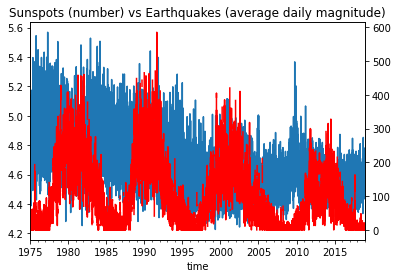

In [26]:
#daily_sunspots["tot"]["1980-01-01":"2019-01-01"].plot()
#daily_quakes['mag'] = 50 * daily_quakes['mag']
#daily_quakes['mag']["1980-01-01":"2019-01-01"].plot()
#print(sframe.corrwith(sundf))
#print(sunframe[0].corrwith(sframe['mag']))

ax = daily_quakes['mag']["1975-01-01":"2019-01-01"].plot(title='Sunspots (number) vs Earthquakes (average daily magnitude)')
#daily_raycount["1975":"2019"].plot(ax=ax1)

#ax.plot(daily_quakes['mag']["1975":"2019"])
ax1 = ax.twinx()
ax1.plot(daily_sunspots["tot"]["1975-01-01":"2019-01-01"], color='red')

In [27]:
# do statistical correlation of sunspots and earthquakes (zero offset)
daily_sunspots["tot"]["1975-01-01":"2018-01-01"].corr(daily_quakes['mag']["1975-01-01":"2018-01-01"], method='pearson')

0.12402736865827761

In [28]:
# offset hunter 1 year  - we look +/- 180 days either side of the 'day' to see how it changes correlation
# e.g. if earthquakes happened more frequently 7 days after a sunspot peak, we should see it
# and if sunspots happen more frequently 15 days after an earthquake, this would show up too
correl_matrix=[]
for var_offset in range (-180, 180):
        offset_ds = daily_sunspots["tot"]["1975-01-01":"2018-01-01"].shift(periods=var_offset)
        #correl_matrix[monthoffset,dayoffset] = daily_quakes['mag']["1980-01-01":"2019-01-01"].corr(offset_ds, method='pearson')
        correl_matrix = correl_matrix + [(daily_quakes['mag']["1975-01-01":"2019-01-01"].corr(offset_ds, method='pearson'))]
        
        

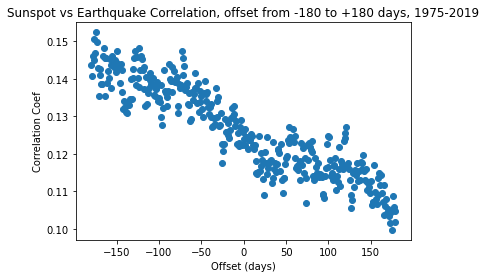

In [29]:
# Here we plot the general correlation vs offset shift (0 is same day)
#print(correl_matrix)
#data = np.array([
#correl_matrix
#])
#x, y = data.T
offset_range = []
offset_range.extend(range(-180,180))
#print(offset_range)
plot.title("Sunspot vs Earthquake Correlation, offset from -180 to +180 days, 1975-2019")
plot.xlabel("Offset (days)")
plot.ylabel("Correlation Coef")
plot.scatter(offset_range,correl_matrix[:])
plot.show()

In [30]:
#offset hunter 1985-2010
# looking for the same thing in a different part of the dataset
correl_matrix_sm=[]
for var_offset in range (-180, 180):
        offset_ds = daily_sunspots["tot"]["1985-01-01":"2010-01-01"].shift(periods=var_offset)
        #correl_matrix[monthoffset,dayoffset] = daily_quakes['mag']["1980-01-01":"2019-01-01"].corr(offset_ds, method='pearson')
        correl_matrix_sm = correl_matrix_sm + [(daily_quakes['mag']["1985-01-01":"2010-01-01"].corr(offset_ds, method='pearson'))]
        
        

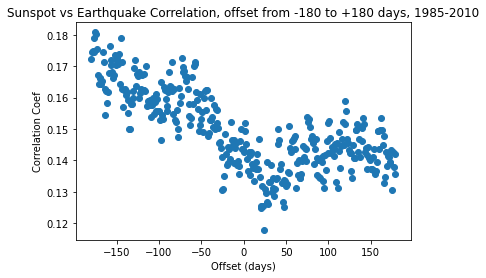

In [37]:
# plot the different range
offset_range = []
offset_range.extend(range(-180,180))
#print(offset_range)
plot.title("Sunspot vs Earthquake Correlation, offset from -180 to +180 days, 1985-2010")
plot.xlabel("Offset (days)")
plot.ylabel("Correlation Coef")
plot.scatter(offset_range,correl_matrix_sm[:])
plot.show()

In [31]:
# offset hunter 10k days (takes a long time to run)
# we also calculate p values, a large p = low statistical/confidence significance
# a very low p = high confidence interval
# (we want a high correlation and a low p for something 'useful')
correl_matrix_smt = []
corr_p = []
for var_offset in range (-10000, 10000):
    offset_ds = daily_sunspots["tot"]["1975":"2019"].shift(periods=var_offset)
    #correl_matrix[monthoffset,dayoffset] = daily_quakes['mag']["1980-01-01":"2019-01-01"].corr(offset_ds, method='pearson')
    correl_matrix_smt = correl_matrix_smt + [(daily_quakes['mag']["1975":"2019"].corr(offset_ds, method='pearson'))]
    corr_p = corr_p + [(daily_quakes['mag']["1975":"2019"].corr(offset_ds, method=pearsonr_pval))]        

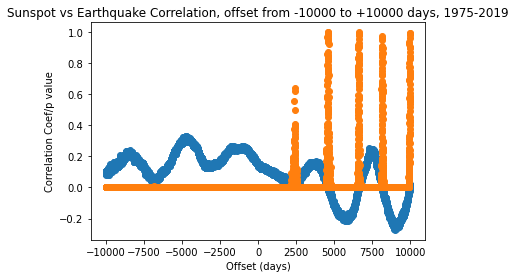

In [32]:
# plot large scale offsets (correlation and p values)
offset_range = []
offset_range.extend(range(-10000,10000))
#print(offset_range)
plot.title("Sunspot vs Earthquake Correlation, offset from -10000 to +10000 days, 1975-2019")
plot.xlabel("Offset (days)")
plot.ylabel("Correlation Coef/p value")
plot.scatter(offset_range,correl_matrix_smt[:])
plot.scatter(offset_range,corr_p[:])

plot.show()

In [33]:
# print a text summary of th emost significant values...
print("Maximum correlation coef =", max(correl_matrix_smt[:]))
print("Lowest P value = ", min(corr_p[:]))
print("Offset for maximum correlation = ", -correl_matrix_smt.index(max(correl_matrix_smt[:])))
print("Offset for lowest P value = ", corr_p.index(min(corr_p[:])))
print("Offset in years =", (correl_matrix_smt.index(max(correl_matrix_smt[:]))/365.25))
#years ago - max historical correlation
#sunspots from 9 years ago = 35% correlation with high confidence earthquake intensity today...

Maximum correlation coef = 0.3318872530602409
Lowest P value =  1.9197353657904475e-235
Offset for maximum correlation =  -5267
Offset for lowest P value =  5267
Offset in years = 14.420260095824778


In [34]:
# how many stations in the dataset?
#print(combineddata[21].columns.values)
#columhead = combineddata[21].columns.values
len(combineddata)

44

In [35]:
# megarayhunter - all stations; run the same thing across them to see if we see differences
# doesn't work yet! - This is about where I'm at in development.
correl_matrix_smt=[]
corr_p =[]
daily_raycount = []
   
for station in range(0,43):
    combineddata[station] = combineddata[station].resample(average_interval, origin='1960-01-01').mean()
    #print(combineddata[station])
    daily_raycount.append(combineddata[station])
print(daily_raycount[0]["1975":"2019"].shift(periods=10))

                        AATA
start_date_time             
2019-01-04               NaN
2019-01-05               NaN
2019-01-06               NaN
2019-01-07               NaN
2019-01-08               NaN
...                      ...
2019-12-27       3767.550000
2019-12-28       3763.804167
2019-12-29       3764.147500
2019-12-30       3751.696250
2019-12-31       3769.609583

[362 rows x 1 columns]


In [37]:
print(daily_raycount[5]["1975":"2019"].shift(periods=10))

                       BKSN
start_date_time            
2009-05-18              NaN
2009-05-19              NaN
2009-05-20              NaN
2009-05-21              NaN
2009-05-22              NaN
...                     ...
2019-12-27       123.888208
2019-12-28       123.903042
2019-12-29       123.562125
2019-12-30       123.711542
2019-12-31       123.954917

[3880 rows x 1 columns]


AATA
AATB
APTY
ARNM
ATHN
BKSN
CALM
DJON
DOMB
DOMC
DRBS
FSMT
HRMS
INVK
IRK2
IRK3
IRKT
JBGO
JUNG
JUNG1
KERG
KIEL
KIEL2
LMKS
MCRL
MGDN
MOSC
MRNY
MXCO
NAIN
NANM
NEWK
NRLK
OULU
PSNM
PTFM
PWNK
ROME
SNAE
SOPB
SOPO
TERA


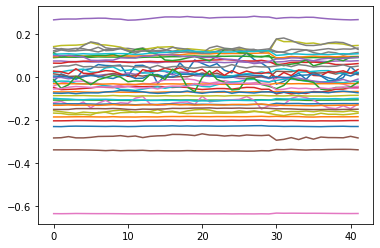

In [83]:
del offset_ds
del correl_matrix_smf
del corr_pf
dayrange = 30
day_set_range = []
day_set_range.extend(range(-dayrange,dayrange))

correl_matrix_smf = [[]]
corr_pf = [[]]
offset_ds = []
cosmic_quake = [[0 for x in range (0,42)] for y in range (-dayrange, dayrange)]

for station in range(0,42):   
    print(station_names[station])
    for var_offset in range (-dayrange, dayrange):
        local_offset = []
        local_offset = daily_raycount[station]["1975":"2019"].shift(periods=var_offset)
        fs = pd.Series(local_offset[station_names[station]])
        #correl_matrix_smf = correl_matrix_smf + 
        #print(var_offset, daily_quakes['mag']["1975":"2019"].corr(fs, method='pearson'))
        cosmic_quake[station][var_offset] = daily_quakes['mag']["1975":"2019"].corr(fs, method='pearson')
    #print(len(cosmic_quake))    
    flagplot = pd.to_numeric(cosmic_quake[station][:], errors='coerce')
    #flagplot.plot()
    #print(len(flagplot[station]))
    #plot.scatter(day_set_range,flagplot)
    plot.plot(flagplot)
    #plot.show()
        #correl_matrix_smf[station] = correl_matrix_smf[station] + daily_quakes['mag']["1975":"2019"].corr(fs, method='pearson')
        #print(correl_matrix_smf) 
        #correl_matrix_smf[station] = correl_matrix_smf[station]+daily_quakes['mag']["1980":"2018"].corr(fs, method='pearson')
        #corr_pf[station] = corr_pf[station] + [daily_quakes['mag']["1975":"2019"].corr(fs, method=pearsonr_pval)]    

#print('offset', offset_ds[:])  
#print('daily quakes', daily_quakes['mag'][:])
#sporkquake = daily_quakes['mag'].to_frame()
#print(sporkquake)
#ts = pd.Series(sporkquake['mag'])
#fs = pd.Series(offset_ds[station_names[1]])
#print(type(sporkquake.to_series()))
#print(type(offset_ds.to_series()))
#print(sporkquake["1975":"2019"])
#print('offset again', offset_ds)
#print('print ts',ts)
#print('print fs', fs)
#print(sporkquake.corr(offset_ds, method='pearson'))
#correl_matrix_smf = ts["1975":"2019"].corr(fs, method='pearson')
#print(correl_matrix_smf)   

#offset_range = []
#offset_range.extend(range(-10000,10000))
#print(offset_range)

#plot.scatter(range (-30, 30),cosmic_quake[0][range (-30, 30)])
#plot.scatter(offset_range,corr_p[:])

#flagplot = pd.to_numeric(cosmic_quake[station], errors='coerce')
#flagplot.plot()
#plot.plot(flagplot)
#plot.show()

ValueError: x and y must be the same size

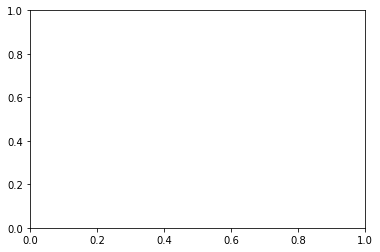

In [146]:
plot.scatter(offset_range,correl_matrix_smf[:], label="Daily cosmics (THUL) correlated with average daily earthquake score (log-average/24h)")
plot.scatter(offset_range,corr_pf[:], label = "p value for correlation, (pearson)")

plot.legend()
plot.title('Time shifted correlation between cosmic rays [THUL] and earthquakes')
plot.xlabel("Timeshift (days)")
plot.ylabel("Correlation and p-value")
plot.show()

In [63]:
print(min(correl_matrix_smf[:]))
print(min(corr_pf[:]))
print(10000-correl_matrix_smf.index(min(correl_matrix_smf[:])))
print(10000-corr_pf.index(min(corr_pf[:])))
print(max(correl_matrix_smf[:]))
print(10000-correl_matrix_smf.index(max(correl_matrix_smf[:])))


-0.356109919072931
1.9058301817431175e-204
3993
3993
0.21851890422627762
-5209


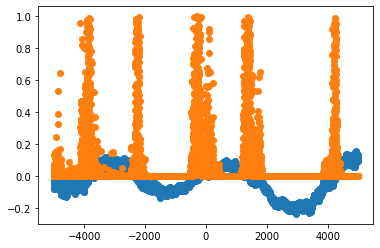

In [65]:
correl_matrix_smf = []
corr_pf = []
for var_offset in range (-5000, 5000):
    offset_ds = daily_raycount["1999":"2019"].shift(periods=var_offset)
    correl_matrix_smf = correl_matrix_smf + [daily_quakes['mag']["1999":"2019"].corr(offset_ds['MXCO'], method='pearson')]
    corr_pf = corr_pf + [daily_quakes['mag']["1999":"2019"].corr(offset_ds['MXCO'], method=pearsonr_pval)]    
#print(correl_matrix_smt)  

offset_range = []
offset_range.extend(range(-5000,5000))
#print(offset_range)

plot.scatter(offset_range,correl_matrix_smf[:])
plot.scatter(offset_range,corr_pf[:])

plot.show()

In [66]:
correl_matrix_smft = []
corr_pft = []
for var_offset in range (-10000, 10000):
    offset_ds = daily_raycount["1975":"2019"].shift(periods=var_offset)
    correl_matrix_smft = correl_matrix_smft + [sundf["tot"]["1975":"2019"].corr(offset_ds['MXCO'], method='pearson')]
    corr_pft = corr_pft + [sundf["tot"]["1975":"2019"].corr(offset_ds['MXCO'], method=pearsonr_pval)]    
#print(correl_matrix_smt)  

offset_range = []
offset_range.extend(range(-10000,10000))
#print(offset_range)


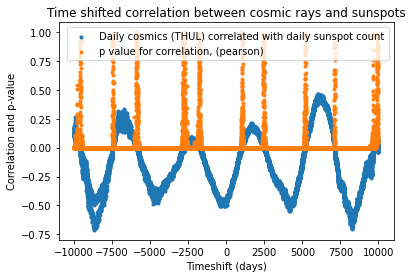

-0.7123943441942397
8707


In [68]:

plot.scatter(offset_range,correl_matrix_smft[:],marker='.',  label="Daily cosmics (THUL) correlated with daily sunspot count")
plot.scatter(offset_range,corr_pft[:], marker='.', label = "p value for correlation, (pearson)")
plot.legend()
plot.title('Time shifted correlation between cosmic rays and sunspots')
plot.xlabel("Timeshift (days)")
plot.ylabel("Correlation and p-value")
plot.show()

print(min(correl_matrix_smft[:]))
print(10000-correl_matrix_smft.index(min(correl_matrix_smft[:])))

<AxesSubplot:title={'center':'Daily earthquakes'}, xlabel='time'>

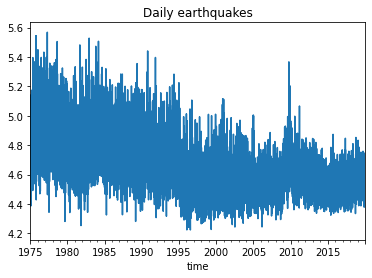

In [69]:
daily_quakes['mag']["1975":"2019"].plot(title='Daily earthquakes')


<AxesSubplot:xlabel='time'>

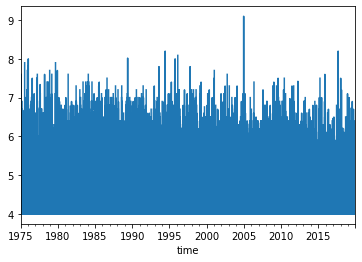

In [70]:
hour_quakes = sframe_notz.resample('1H', origin='1975-01-01').apply(lambda spl: 10*np.log10(np.mean(np.power(10, spl/10))))
hour_quakes['mag']["1975":"2019"].plot()

In [ ]:
#morning to do
#add labels to all plots
#run for all cosmic ray stations
#extend seismic data to all events (not just cut off at 4)
#conduct dimensionless analysis (same thing with delta variable in time from frame-frame)
#change the timebase for analysis - 1h, 3h, 6h, 12h, 24h, 5d, 7d, 1m
#quality score for each cosmic ray station (period on, amount of data collected - as a rank)
#random series test correlation


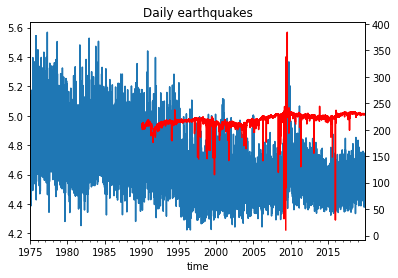

In [71]:
#daily_quakes['mag'] = 1/2 * daily_quakes['mag']
ax = daily_quakes['mag']["1975":"2019"].plot(title='Daily earthquakes')
#daily_raycount["1975":"2019"].plot(ax=ax1)

#ax.plot(daily_quakes['mag']["1975":"2019"])
ax1 = ax.twinx()
ax1.plot(daily_raycount["1975":"2019"], color='red')


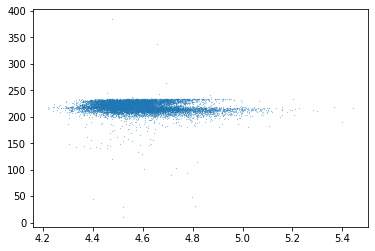

In [90]:
#plot at 0 intersection (day/day)
plot.scatter(daily_quakes['mag']["1990":"2019"],daily_raycount["1990":"2019"], marker='.',s=0.1, label="Daily cosmics (THUL) vs Earthquake magnitude")


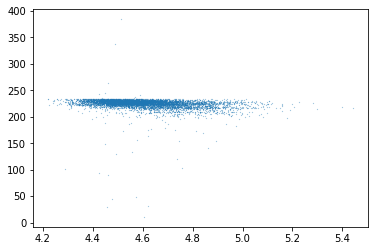

In [89]:
#plot at -5000 days intersection
offset_ds_plot = daily_raycount["1990":"2019"].shift(periods=-4913)
plot.scatter(daily_quakes['mag']["1990":"2019"],offset_ds_plot, marker='.', s=0.1,label="Daily cosmics (THUL) vs Earthquake magnitude")


                       MXCO
start_date_time            
1990-01-01              NaN
1990-01-02              NaN
1990-01-03              NaN
1990-01-04              NaN
1990-01-05              NaN
...                     ...
2018-12-27       216.433909
2018-12-28       216.217667
2018-12-29       215.789875
2018-12-30       215.544792
2018-12-31       216.536957

[10592 rows x 1 columns]
time
1990-01-01    4.993210
1990-01-02    4.835273
1990-01-03    4.509206
1990-01-04    4.700446
1990-01-05    4.823279
                ...   
2018-12-27    4.570452
2018-12-28    4.559079
2018-12-29    4.673080
2018-12-30    4.510135
2018-12-31    4.512682
Freq: D, Name: mag, Length: 10592, dtype: float64


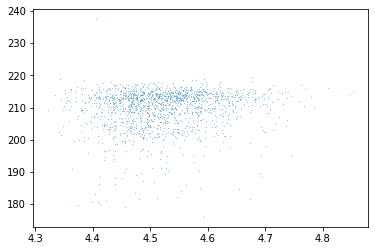

In [87]:
#plot at -5000 days intersection (positive correlation - max future)
offset_ds_plot = daily_raycount["1990":"2018"].shift(periods=8882)
plot.scatter(daily_quakes['mag']["1990":"2018"],offset_ds_plot, marker='.',s=0.1, label="Daily cosmics (THUL) vs Earthquake magnitude")

print(offset_ds_plot)
print(daily_quakes['mag']["1990":"2018"])


                       MXCO
start_date_time            
1992-01-01              NaN
1992-01-02              NaN
1992-01-03              NaN
1992-01-04              NaN
1992-01-05              NaN
...                     ...
2016-12-27       224.173625
2016-12-28       225.840208
2016-12-29       226.912375
2016-12-30       225.899125
2016-12-31       222.014833

[9132 rows x 1 columns]
              tot    sn     ss   diff
time                                 
1992-01-01  240.0   0.0 -240.0 -240.0
1992-01-02  241.0  39.0 -203.0 -164.0
1992-01-03  301.0  25.0 -277.0 -251.0
1992-01-04  310.0  69.0 -241.0 -171.0
1992-01-05  338.0  85.0 -253.0 -167.0
...           ...   ...    ...    ...
2016-12-27   27.0  27.0    0.0   27.0
2016-12-28   11.0  11.0    0.0   11.0
2016-12-29   11.0  11.0    0.0   11.0
2016-12-30   11.0  11.0    0.0   11.0
2016-12-31   41.0  21.0  -21.0    0.0

[9132 rows x 4 columns]


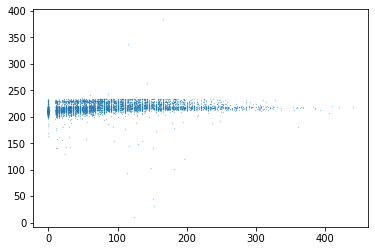

In [86]:
#plot at -5000 days intersection (positive correlation - max future)
offset_ds_plotf = daily_raycount["1992":"2016"].shift(periods=2000)
print(offset_ds_plotf)
print(daily_sunspots["1992":"2016"])
plot.scatter(daily_sunspots['tot']["1992":"2016"],offset_ds_plotf, marker='.',s=0.1, label="Daily cosmics (THUL) vs Earthquake magnitude")
